# Figure 2: DFT Validation — VASP Reference Comparison
Grouped bar chart comparing Adsorb-Agent, VASP (PBE), and AdsMind adsorption energies across 6 representative CMU20 systems.


In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.transforms as mtransforms
import numpy as np
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ---- Unified paper_plots style ----
plt.style.use('default')
sns.set_theme(style='ticks', context='paper', font_scale=1.2)
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
# ---- Data ----
systems = [
    'H\nMo$_3$Pd(111)',
    'NNH\nMo$_3$Pd(111)',
    'H\nCuPd$_3$(111)',
    'NNH\nCuPd$_3$(111)',
    'OH\nPt(111)',
    'OH\nPt(100)',
]
# 1, 2, 3, 4, 9, 10
adsorb_agent = [-0.764, -1.265, -0.380,  0.745,  0.990,  0.991]
vasp         = [-1.122, -3.066, -0.319, -0.996, -2.594, -2.511]
adsmind      = [-3.619, -4.342, -3.351, -2.285, -1.991, -2.717]
AdsMind_mace_large= [-3.627, -4.769, -3.352, -2.255, -1.991, -2.710]
# Compute MAE
mae_aa = np.mean(np.abs(np.array(adsorb_agent) - np.array(vasp)))
mae_am = np.mean(np.abs(np.array(adsmind) - np.array(vasp)))
mae_al = np.mean(np.abs(np.array(AdsMind_mace_large) - np.array(vasp)))
print(f'MAE Adsorb-Agent vs VASP: {mae_aa:.2f} eV')
print(f'MAE AdsMind-Mace-small vs VASP: {mae_am:.2f} eV')
print(f'MAE AdsMind-Mace-Large vs VASP: {mae_al:.2f} eV')

MAE Adsorb-Agent vs VASP: 1.84 eV
MAE AdsMind-Mace-small vs VASP: 1.48 eV
MAE AdsMind-Mace-Large vs VASP: 1.55 eV


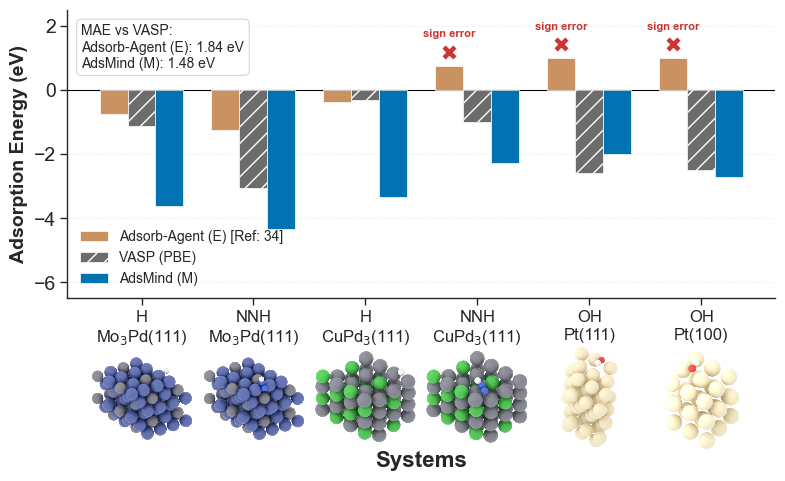

Saved: figure2_vasp_validation.png


In [3]:
# ---- Plot: Grouped bar chart ----
x = np.arange(len(systems))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))

colors = ['#CA9161', '#6C6C6C', '#0173b2']

# Bars
bars_aa = ax.bar(x - width, adsorb_agent, width, label='Adsorb-Agent (E) [Ref: 34]',
                color=colors[0], edgecolor='white', linewidth=0.5, zorder=3)
bars_vasp = ax.bar(x, vasp, width, label='VASP (PBE)',
                  color=colors[1], edgecolor='white', linewidth=0.5, hatch='//', zorder=3)
bars_am = ax.bar(x + width, adsmind, width, label='AdsMind (M)',
                color=colors[2], edgecolor='white', linewidth=0.5, zorder=3)

# Mark sign errors with bold filled-X scatter markers
sign_error_idx = [3, 4, 5]
for idx in sign_error_idx:
    cx = x[idx] - width
    cy = max(0, adsorb_agent[idx]) + 0.45
    ax.scatter(cx, cy, marker='X', s=120, color='#CC3333',
               edgecolors='white', linewidths=0.6, zorder=10)
    ax.annotate('sign error', (x[idx] - width, max(0, adsorb_agent[idx]) + 0.9),
                ha='center', fontsize=8, color='#CC3333', fontweight='bold')

# Zero reference line
ax.axhline(y=0, color='black', linewidth=0.8, zorder=2)

# Labels and ticks
ax.set_ylabel('Adsorption Energy (eV)', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=12)
ax.set_ylim(-6.5, 2.5)

# Placeholder schematics under x-axis (reference images)
ref_dir = 'reference'
ref_images = [
    '01_Mo3Pd_111_H_template_v6.png',
    '02_Mo3Pd_111_NNH.png',
    '03_Pd3Cu_111_H.png',
    '04_Pd3Cu_111_NNH.png',
    '09_Pt_111_OH.png',
    '10_Pt_100_OH.png',
]
transform = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for i, xi in enumerate(x):
    img_path = os.path.join(ref_dir, ref_images[i % len(ref_images)])
    img = plt.imread(img_path)
    image = OffsetImage(img, zoom=0.08)
    ab = AnnotationBbox(
        image,
        (xi, -0.15),
        xycoords=transform,
        frameon=False,
        box_alignment=(0.5, 1.0),
    )
    ax.add_artist(ab)

# Legend without frame
ax.legend(frameon=False, fontsize=10, loc='lower left')

# Grid
ax.grid(True, axis='y', alpha=0.25, linestyle='--', linewidth=0.65)
ax.grid(False, axis='x')
ax.set_axisbelow(True)

# MAE annotation in top-left corner
ax.text(0.02, 0.95,
        f'MAE vs VASP:\nAdsorb-Agent (E): {mae_aa:.2f} eV\nAdsMind (M): {mae_am:.2f} eV',
        transform=ax.transAxes, ha='left', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.8, edgecolor='#cccccc'))
ax.set_xlabel('Systems', fontsize=16, fontweight='bold', labelpad=75)# set the position of x-axis label lower

plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.show()
# ---- Save ----
out_dir = '.'
fig.savefig(f'{out_dir}/figure2_vasp_validation.png', dpi=300, bbox_inches='tight')
print('Saved: figure2_vasp_validation.png')